# Dataset & DataModule smoke tests

Phase 1/2 of the migration is done: `KittiMonoDataset` (HDF5-backed), the runtime
`transforms.py` pipeline, `collate_fn`, and `KittiDataModule`. This notebook verifies
that they actually wire together against the packed `data.h5` files:

1. **Hydra config** composes and resolves (`configs/config.yaml`).
2. **Raw dataset** (`transform=None`) returns sample dicts of the right shapes/dtypes.
3. **Transforms** preserve shapes, normalize correctly, and the photometric/mirror
   design decisions hold (shared params → zero residual; mirror reflects boxes).
4. **DataModule + DataLoader** yield the legacy tuple contract (train 7-tuple,
   val 6-tuple) at the configured batch size.
5. A quick **visualization** sanity-check of the projected 2D boxes.

> Run inside the `ai_ev` container's Jupyter (deps + `data.h5` live there).

In [ ]:
import os, sys
from pathlib import Path

# Locate the project root (dir holding .project-root) and wire up the same env the
# entrypoint scripts set: PROJECT_ROOT for configs/paths, and src/ on sys.path
# (the monowad package is not pip-installed in the container — see CLAUDE.md).
def _find_root() -> Path:
    cwd = Path.cwd()
    # 1) walk up from the working dir
    for p in (cwd, *cwd.parents):
        if (p / ".project-root").exists():
            return p
    # 2) cheap known candidates (container mount / host checkout, and a my_implementation
    #    child if Jupyter launched one level up at the repo/mount root)
    for cand in (
        cwd / "my_implementation",
        Path("/workspace/my_implementation"),
        Path.home() / "ai_ev/ShortcutMonoWAD/my_implementation",
    ):
        if (cand / ".project-root").exists():
            return cand
    # 3) last resort: scan downward (may be slow on a large tree)
    for marker in cwd.rglob(".project-root"):
        return marker.parent
    raise FileNotFoundError("could not locate .project-root — run this from inside my_implementation")

ROOT = _find_root()
os.environ["PROJECT_ROOT"] = str(ROOT)
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import torch

from monowad.data.dataset import KittiMonoDataset
from monowad.data.datamodule import KittiDataModule
from monowad.data.transforms import (
    build_train_transform,
    build_eval_transform,
    PhotometricDistort,
    RandomMirror,
    ConvertToFloat,
)

print("project root :", ROOT)
print("monowad pkg  :", Path(KittiMonoDataset.__module__.replace('.', '/')))
print("torch        :", torch.__version__)

project root : /workspace/my_implementation
monowad pkg  : monowad/data/dataset
torch        : 2.4.0+cu124


## 1. Hydra config composes & resolves

Compose `configs/config.yaml` the same way `scripts/train.py` does and confirm the
interpolations (`${paths.train_dir}/data.h5`, `${oc.env:PROJECT_ROOT}`, …) resolve to
real files.

In [2]:
from hydra import initialize_config_dir, compose
from omegaconf import OmegaConf

with initialize_config_dir(config_dir=str(ROOT / "configs"), version_base=None):
    cfg = compose(config_name="config")

print(OmegaConf.to_yaml(cfg.data))

d = cfg.data
# interpolations resolve to absolute, existing paths
assert Path(d.train_h5).exists(), f"missing {d.train_h5}"
assert Path(d.val_h5).exists(), f"missing {d.val_h5}"
# the values the dataset/transform pipeline depend on are present and sane
assert d.batch_size > 0 and d.num_workers >= 0
assert len(d.rgb_mean) == 3 and len(d.rgb_std) == 3
assert tuple(d.rgb_shape) == (288, 1280)
print("\nconfig OK — train/val h5 resolved, rgb_shape =", tuple(d.rgb_shape))

batch_size: 8
num_workers: 8
pin_memory: true
rgb_shape:
- 288
- 1280
rgb_mean:
- 0.485
- 0.456
- 0.406
rgb_std:
- 0.229
- 0.224
- 0.225
train_h5: ${paths.train_dir}/data.h5
val_h5: ${paths.val_dir}/data.h5
anchor_mean: ${paths.train_dir}/anchor_mean_Car.npy
anchor_std: ${paths.train_dir}/anchor_std_Car.npy


config OK — train/val h5 resolved, rgb_shape = (288, 1280)


## 2. Raw dataset (`transform=None`)

Instantiate the dataset with no augmentation so we see exactly what comes out of the
h5 (uint8 images, post-resize `P2`, raw KITTI labels reprojected to `bbox3d`/`bbox2d`).
Check the length matches the documented frame counts and a sample has the right keys,
shapes, and dtypes — for both the train split (has depth) and the val split (no depth).

In [3]:
train_raw = KittiMonoDataset(d.train_h5, transform=None)
val_raw = KittiMonoDataset(d.val_h5, transform=None)

print(f"train frames: {len(train_raw)}   (has_depth={train_raw.has_depth}, has_foggy={train_raw.has_foggy})")
print(f"val   frames: {len(val_raw)}   (has_depth={val_raw.has_depth}, has_foggy={val_raw.has_foggy})")
assert len(train_raw) == 3712
assert len(val_raw) == 3769
assert train_raw.has_depth and not val_raw.has_depth

s = train_raw[0]
print("\nsample keys:", sorted(s.keys()))
for k in ("image", "foggy", "calib", "depth", "bbox2d", "bbox3d"):
    v = s[k]
    print(f"  {k:8s} shape={None if v is None else np.shape(v)}  dtype={None if v is None else np.asarray(v).dtype}")
print("  label   :", s["label"])

H, W = d.rgb_shape
assert s["image"].shape == (H, W, 3) and s["image"].dtype == np.uint8
assert s["foggy"].shape == (H, W, 3)
assert s["calib"].shape == (3, 4)
assert s["depth"].shape == (H // 4, W // 4)            # ¼-res depth GT
N = len(s["label"])
assert s["bbox2d"].shape == (N, 4)                      # x1,y1,x2,y2
assert s["bbox3d"].shape == (N, 7)                      # proj_cx,proj_cy,z,w,h,l,alpha
print(f"\nraw sample OK — {N} object(s), image {s['image'].shape}, depth {s['depth'].shape}")

train frames: 3712   (has_depth=True, has_foggy=True)
val   frames: 3769   (has_depth=False, has_foggy=True)

sample keys: ['bbox2d', 'bbox3d', 'calib', 'depth', 'foggy', 'image', 'label', 'original_P', 'original_shape']
  image    shape=(288, 1280, 3)  dtype=uint8
  foggy    shape=(288, 1280, 3)  dtype=uint8
  calib    shape=(3, 4)  dtype=float32
  depth    shape=(72, 320)  dtype=uint8
  bbox2d   shape=(0, 4)  dtype=float32
  bbox3d   shape=(0, 7)  dtype=float32
  label   : []

raw sample OK — 0 object(s), image (288, 1280, 3), depth (72, 320)


In [4]:
# Zero-label edge case: scan for a frame with no objects and confirm empty (0, k) boxes.
empty_idx = next((i for i in range(200) if len(train_raw[i]["label"]) == 0), None)
if empty_idx is None:
    print("no zero-label frame in first 200 (fine)")
else:
    e = train_raw[empty_idx]
    assert e["bbox2d"].shape == (0, 4) and e["bbox3d"].shape == (0, 7)
    print(f"frame {empty_idx} has 0 labels → bbox2d {e['bbox2d'].shape}, bbox3d {e['bbox3d'].shape} OK")

frame 0 has 0 labels → bbox2d (0, 4), bbox3d (0, 7) OK


## 3. Transforms

Exercise the pipeline factories and the two design decisions documented in CLAUDE.md:

* **eval** = `ConvertToFloat → Normalize` — deterministic, output is float32 in the
  ImageNet-normalized range; shapes preserved.
* **PhotometricDistort shares params across clear & foggy** — if `clear == foggy` going
  in, the residual stays exactly 0 coming out.
* **RandomMirror reflects in place, no role swap** — image flips horizontally and a
  label's X / 2D box reflect about the width.

In [5]:
eval_tf = build_eval_transform(d.rgb_mean, d.rgb_std)
train_tf = build_train_transform(d.rgb_mean, d.rgb_std)

# pull a raw sample to feed the transforms directly (clear, foggy, P2, labels, depth)
import copy
raw = train_raw[0]
clear0 = raw["image"].copy()
foggy0 = raw["foggy"].copy()
P20 = raw["calib"].copy()

# --- eval: deterministic + normalized ---
c1, f1, _, _, _ = eval_tf(clear0.copy(), foggy0.copy(), P20.copy(), [], None)
c2, _, _, _, _ = eval_tf(clear0.copy(), foggy0.copy(), P20.copy(), [], None)
assert c1.dtype == np.float32 and c1.shape == clear0.shape
assert np.array_equal(c1, c2), "eval transform must be deterministic"
print("eval transform: float32, shape preserved, deterministic")
print(f"  normalized clear range [{c1.min():+.2f}, {c1.max():+.2f}], per-channel mean {c1.reshape(-1,3).mean(0).round(2)}")
assert -5.0 < c1.min() and c1.max() < 5.0

# --- photometric: shared params → zero residual when clear==foggy ---
same = clear0.astype(np.float32)
pc, pf, _, _, _ = PhotometricDistort()(same.copy(), same.copy(), P20.copy(), [], None)
resid = np.abs(pc - pf).max()
print(f"\nphotometric shared-param residual (clear==foggy in): {resid:.6f}")
assert resid == 0.0, "clear and foggy must receive identical photometric params"
assert not np.array_equal(pc, same), "distort with prob=1 should actually change the image"

eval transform: float32, shape preserved, deterministic
  normalized clear range [-2.10, +2.64], per-channel mean [-0.66 -0.38 -0.12]

photometric shared-param residual (clear==foggy in): 0.000000


In [6]:
# --- mirror: in-place reflection of image, P2, and labels (prob=1) ---
# pick the first frame that actually has labels so the box checks are meaningful
src = next((i for i in range(len(train_raw)) if train_raw._labels(train_raw._file(), i)), 0)
labels = copy.deepcopy(train_raw._labels(train_raw._file(), src))
img = train_raw[src]["image"].astype(np.float32)
P2 = train_raw[src]["calib"].copy()

before_x = [o.x for o in labels]
before_cx = P2[0, 2]
mc, _, P2m, lab_m, _ = RandomMirror(mirror_prob=1.0)(img.copy(), None, P2.copy(), copy.deepcopy(labels), None)

assert np.array_equal(mc, img[:, ::-1, :]), "clear image must be horizontally flipped"
assert np.allclose([o.x for o in lab_m], [-x for x in before_x]), "3D X must flip sign"
assert np.isclose(P2m[0, 2], img.shape[1] - before_cx - 1), "principal point cx must reflect about width"
print(f"mirror: image flipped, {len(labels)} label X-signs flipped, cx {before_cx:.1f} → {P2m[0,2]:.1f} (W={img.shape[1]})")

mirror: image flipped, 1 label X-signs flipped, cx 638.4 → 640.6 (W=1280)


## 4. DataModule + DataLoader — the tuple contract

Build `KittiDataModule(cfg)`, `setup("fit")`, and pull one batch from each loader.
Train must yield the **7-tuple** `(rgb, calib, labels, bbox2d, bbox3d, depth, foggy)`
and val the **6-tuple** `(rgb, calib, labels, bbox2d, bbox3d, foggy)`, both at
`batch_size`, with `rgb` shaped `[B, 3, H, W]`.

> `num_workers` is forced to 0 here so the loader runs in-process inside the notebook.

In [7]:
from omegaconf import open_dict

with open_dict(cfg):
    cfg.data.num_workers = 0          # single-process for the notebook

dm = KittiDataModule(cfg)
dm.setup("fit")
print("obj_types:", dm.obj_types)
print("train set:", len(dm.train_set), " val set:", len(dm.val_set))

B = cfg.data.batch_size
H, W = cfg.data.rgb_shape

train_batch = next(iter(dm.train_dataloader()))
val_batch = next(iter(dm.val_dataloader()))
print(f"\ntrain batch: {len(train_batch)}-tuple")
print(f"val   batch: {len(val_batch)}-tuple")
assert len(train_batch) == 7, "train loader must yield the 7-tuple (with depth + foggy)"
assert len(val_batch) == 6, "val loader must yield the 6-tuple (foggy, no depth)"

rgb, calib, labels, bbox2d, bbox3d, depth, foggy = train_batch
print("\ntrain tuple shapes:")
print(f"  rgb    {tuple(rgb.shape)}  {rgb.dtype}")
print(f"  calib  {tuple(calib.shape)}")
print(f"  depth  {tuple(depth.shape)}")
print(f"  foggy  {tuple(foggy.shape)}")
print(f"  labels : list of {len(labels)} (per-frame, ragged)  e.g. {labels[0]}")
print(f"  bbox2d : list of {len(bbox2d)}  shapes {[b.shape for b in bbox2d[:3]]}...")
print(f"  bbox3d : list of {len(bbox3d)}  shapes {[b.shape for b in bbox3d[:3]]}...")

assert rgb.shape == (B, 3, H, W) and rgb.dtype == torch.float32
assert calib.shape == (B, 3, 4)
assert depth.shape == (B, H // 4, W // 4)
assert foggy.shape == (B, 3, H, W)
assert len(labels) == len(bbox2d) == len(bbox3d) == B
for i in range(B):
    n = len(labels[i])
    assert bbox2d[i].shape == (n, 4) and bbox3d[i].shape == (n, 7)

rgb_v, *_ , foggy_v = val_batch
assert rgb_v.shape == (B, 3, H, W) and foggy_v.shape == (B, 3, H, W)
print("\nDataModule OK — train 7-tuple / val 6-tuple, batch size", B)

obj_types: ('Car',)
train set: 3712  val set: 3769

train batch: 7-tuple
val   batch: 6-tuple

train tuple shapes:
  rgb    (8, 3, 288, 1280)  torch.float32
  calib  (8, 3, 4)
  depth  (8, 72, 320)
  foggy  (8, 3, 288, 1280)
  labels : list of 8 (per-frame, ragged)  e.g. ['Car', 'Car']
  bbox2d : list of 8  shapes [(2, 4), (4, 4), (6, 4)]...
  bbox3d : list of 8  shapes [(2, 7), (4, 7), (6, 7)]...

DataModule OK — train 7-tuple / val 6-tuple, batch size 8


## 5. Visualization — projected 2D boxes

Draw the reprojected `bbox2d` over a raw (un-normalized) frame to eyeball that the
geometry pipeline lands the boxes on the cars. Clear vs. foggy side by side.

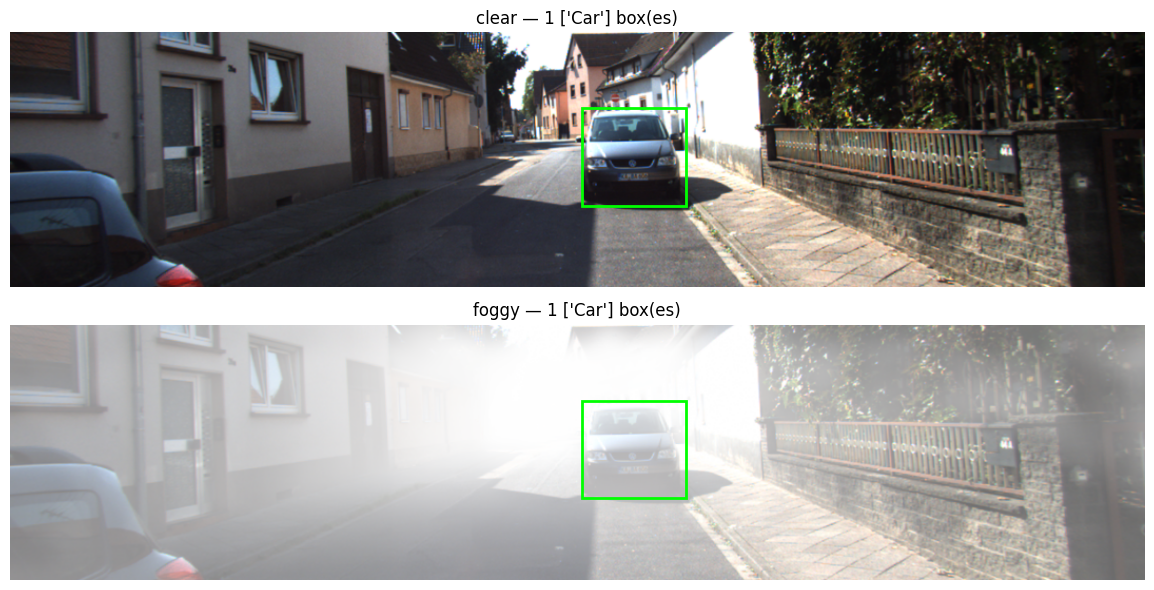

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

viz = train_raw[src]                       # raw uint8 sample with reprojected boxes
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
for ax, key, title in zip(axes, ("image", "foggy"), ("clear", "foggy")):
    ax.imshow(viz[key])
    for (x1, y1, x2, y2) in viz["bbox2d"]:
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                       fill=False, edgecolor="lime", linewidth=2))
    ax.set_title(f"{title} — {len(viz['label'])} {viz['label'][:1]} box(es)")
    ax.axis("off")
plt.tight_layout()
plt.show()